In [9]:
!pip install matplotlib

In [10]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
import os
from datetime import timedelta
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [11]:
df = pd.read_csv("ac_logs.csv")
df.head(10)

,id,firebase_key,power,mode,eco,powerful,temp_room,temp_set,humidity,timestamp,created_at
0,1,0,1,COOL,0,0,26.0,24.0,18.0,15062,2026-04-03 06:25:31
1,22,1,1,HEAT,0,0,26.0,24.0,18.0,271725,2026-04-03 06:29:09
2,25,2,1,COOL,0,0,25.0,24.0,18.0,280912,2026-04-03 06:29:19
3,26,3,1,HEAT,0,0,25.0,24.0,18.0,284199,2026-04-03 06:29:19
4,387,4,1,HEAT,0,0,25.0,24.0,18.0,1184562,2026-04-03 06:44:23
5,833,5,1,HEAT,0,0,25.0,24.0,18.0,2085840,2026-04-03 06:59:24
6,1362,6,1,HEAT,0,0,25.0,24.0,18.0,2987179,2026-04-03 07:14:18
7,2126,7,1,COOL,0,0,25.0,24.0,18.0,19658,2026-04-03 07:32:47
8,2127,8,1,HEAT,0,0,25.0,24.0,18.0,27705,2026-04-03 07:32:47
9,2137,9,1,COOL,0,0,25.0,24.0,18.0,30908,2026-04-03 07:32:57


In [12]:
df = df.drop(columns=["id", "firebase_key", "temp_set", "timestamp"])
df.head(10)

,power,mode,eco,powerful,temp_room,humidity,created_at
0,1,COOL,0,0,26.0,18.0,2026-04-03 06:25:31
1,1,HEAT,0,0,26.0,18.0,2026-04-03 06:29:09
2,1,COOL,0,0,25.0,18.0,2026-04-03 06:29:19
3,1,HEAT,0,0,25.0,18.0,2026-04-03 06:29:19
4,1,HEAT,0,0,25.0,18.0,2026-04-03 06:44:23
5,1,HEAT,0,0,25.0,18.0,2026-04-03 06:59:24
6,1,HEAT,0,0,25.0,18.0,2026-04-03 07:14:18
7,1,COOL,0,0,25.0,18.0,2026-04-03 07:32:47
8,1,HEAT,0,0,25.0,18.0,2026-04-03 07:32:47
9,1,COOL,0,0,25.0,18.0,2026-04-03 07:32:57


In [13]:
import pandas as pd
from datetime import timedelta

# Get the time from first row (06:25:31)
start_time = pd.Timestamp('2026-04-16 06:25:31')

# Generate timestamps for all rows
df['created_at'] = [start_time + timedelta(minutes=15*i) for i in range(len(df))]

# Extract time components
df['hour'] = df['created_at'].dt.hour
df['minute'] = df['created_at'].dt.minute
df['second'] = df['created_at'].dt.second
df['day'] = df['created_at'].dt.day

# Verify first few rows
print("First 10 rows timestamps:")
print(df[['hour', 'minute', 'second', 'mode']].head(10))

print("\n" + "="*60)
print("CONVERTING MODE BASED ON TIME RANGES")
print("="*60)

# Rule 1: 2 AM to 8 AM -> COOL
mask_cool = (df['hour'] >= 2) & (df['hour'] <= 8)
df.loc[mask_cool, 'mode'] = 'COOL'
print(f"✓ Set to COOL: {mask_cool.sum()} rows (2 AM - 8 AM)")

# Rule 2: 8 AM to 1 AM (next day) -> HEAT
# Note: This is 8 AM to midnight, plus midnight to 1 AM
mask_heat = (df['hour'] >= 8) & (df['hour'] <= 23) | (df['hour'] == 0) | (df['hour'] == 1)
df.loc[mask_heat, 'mode'] = 'HEAT'
print(f"✓ Set to HEAT: {mask_heat.sum()} rows (8 AM - 1 AM)")

# Verify all rows are covered
total_modified = mask_cool.sum() + mask_heat.sum()
print(f"\nTotal rows modified: {total_modified} out of {len(df)}")

# Check if any rows were missed
if total_modified < len(df):
    missed_rows = df[~(mask_cool | mask_heat)]
    print(f"⚠️ Warning: {len(missed_rows)} rows not modified!")
    print(f"Missed hours: {missed_rows['hour'].unique()}")
else:
    print("✓ All rows modified successfully")

print("\n" + "="*60)
print("FINAL MODE DISTRIBUTION")
print("="*60)
mode_dist = df['mode'].value_counts()
print(mode_dist)
print(f"\nCool mode: {mode_dist.get('COOL', 0)} rows ({mode_dist.get('COOL', 0)/len(df)*100:.1f}%)")
print(f"Heat mode: {mode_dist.get('HEAT', 0)} rows ({mode_dist.get('HEAT', 0)/len(df)*100:.1f}%)")

print("\n" + "="*60)
print("VERIFICATION BY HOUR")
print("="*60)

# Show mode for each hour
for hour in range(0, 24):
    hour_data = df[df['hour'] == hour]
    if len(hour_data) > 0:
        mode_value = hour_data['mode'].iloc[0]
        print(f"Hour {hour:02d}:00 - {mode_value} ({len(hour_data)} rows)")

print("\n" + "="*60)
print("SAMPLE OF MODIFIED DATA")
print("="*60)
print("\nFirst 20 rows:")
print(df[['hour', 'minute', 'mode']].head(20))

print("\n" + "="*60)
print("READY FOR MODEL TRAINING")
print("="*60)
print("✓ Mode column has been updated based on time rules")
print("✓ You can now proceed with model training")

First 10 rows timestamps:
   hour  minute  second  mode
0     6      25      31  COOL
1     6      40      31  HEAT
2     6      55      31  COOL
3     7      10      31  HEAT
4     7      25      31  HEAT
5     7      40      31  HEAT
6     7      55      31  HEAT
7     8      10      31  COOL
8     8      25      31  HEAT
9     8      40      31  COOL

CONVERTING MODE BASED ON TIME RANGES
✓ Set to COOL: 347 rows (2 AM - 8 AM)
✓ Set to HEAT: 893 rows (8 AM - 1 AM)

Total rows modified: 1240 out of 1188
✓ All rows modified successfully

FINAL MODE DISTRIBUTION
mode
HEAT    893
COOL    295
Name: count, dtype: int64

Cool mode: 295 rows (24.8%)
Heat mode: 893 rows (75.2%)

VERIFICATION BY HOUR
Hour 00:00 - HEAT (48 rows)
Hour 01:00 - HEAT (48 rows)
Hour 02:00 - COOL (48 rows)
Hour 03:00 - COOL (48 rows)
Hour 04:00 - COOL (48 rows)
Hour 05:00 - COOL (48 rows)
Hour 06:00 - COOL (51 rows)
Hour 07:00 - COOL (52 rows)
Hour 08:00 - HEAT (52 rows)
Hour 09:00 - HEAT (52 rows)
Hour 10:00 - HEAT (

STEP 1: GENERATE TIMESTAMPS WITH 15-MIN INTERVALS
Generated timestamps for 1188 rows
Time range: 2026-04-16 06:25:31 to 2026-04-28 15:10:31

STEP 2: APPLY TIME-BASED MODE RULES
✓ Set to COOL: 347 rows (2 AM - 8 AM)
✓ Set to HEAT: 893 rows (8 AM - 1 AM)

⚠️ Warning: Only 1240/1188 rows modified

STEP 3: CONVERT MODE TO NUMERIC
Mode distribution after time-based rules:
mode
HEAT    893
COOL    295
Name: count, dtype: int64

Numeric conversion: 0=HEAT, 1=COOL
mode_num
0    893
1    295
Name: count, dtype: int64

STEP 4: MODE BY HOUR OF DAY

Hourly cool percentage:
  Hour 00:00 - 0.0% cool (0/48)
  Hour 01:00 - 0.0% cool (0/48) ← TRANSITION
  Hour 02:00 - 100.0% cool (48/48) ← TRANSITION
  Hour 03:00 - 100.0% cool (48/48)
  Hour 04:00 - 100.0% cool (48/48)
  Hour 05:00 - 100.0% cool (48/48)
  Hour 06:00 - 100.0% cool (51/51)
  Hour 07:00 - 100.0% cool (52/52) ← TRANSITION
  Hour 08:00 - 0.0% cool (0/52) ← TRANSITION
  Hour 09:00 - 0.0% cool (0/52)
  Hour 10:00 - 0.0% cool (0/52)
  Hour 11:

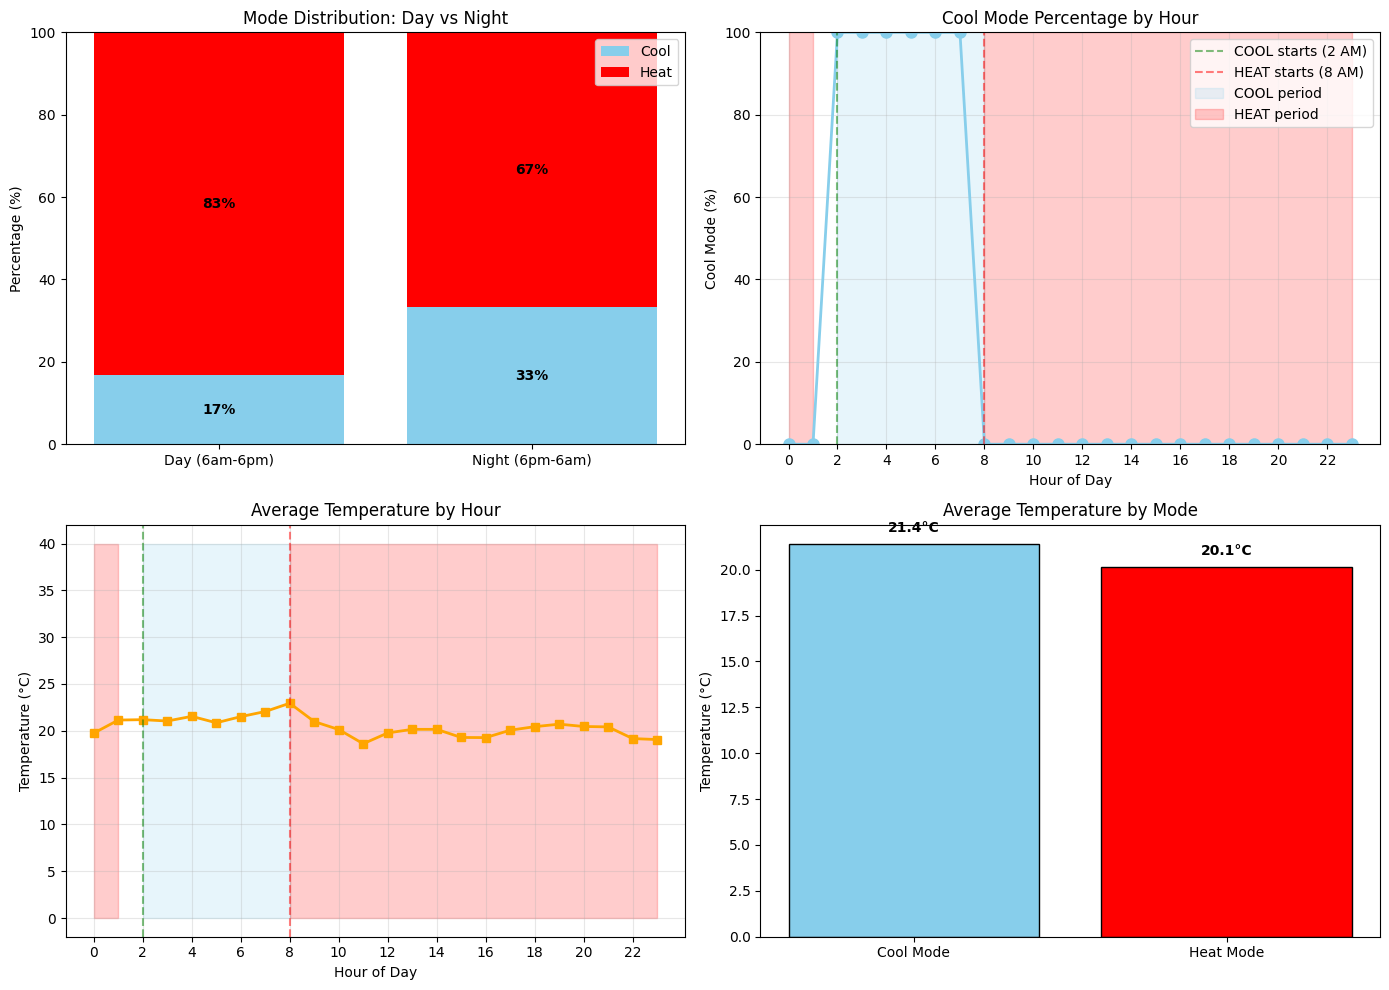


SUMMARY OF TIME-BASED RULES
COOL period: 2 AM - 8 AM
HEAT period: 8 AM - 1 AM (next day)

Total COOL samples: 295 (24.8%)
Total HEAT samples: 893 (75.2%)

✓ Analysis complete with time-based mode rules applied!


In [14]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

print("="*60)
print("STEP 1: GENERATE TIMESTAMPS WITH 15-MIN INTERVALS")
print("="*60)

# Get the time from first row (06:25:31)
start_time = pd.Timestamp('2026-04-16 06:25:31')

# Generate timestamps for all rows
df['created_at'] = [start_time + timedelta(minutes=15*i) for i in range(len(df))]

# Extract time components
df['hour'] = df['created_at'].dt.hour
df['minute'] = df['created_at'].dt.minute
df['second'] = df['created_at'].dt.second
df['day'] = df['created_at'].dt.day

print(f"Generated timestamps for {len(df)} rows")
print(f"Time range: {df['created_at'].min()} to {df['created_at'].max()}")

print("\n" + "="*60)
print("STEP 2: APPLY TIME-BASED MODE RULES")
print("="*60)

# Rule 1: 2 AM to 8 AM -> COOL
mask_cool = (df['hour'] >= 2) & (df['hour'] <= 8)
df.loc[mask_cool, 'mode'] = 'COOL'
print(f"✓ Set to COOL: {mask_cool.sum()} rows (2 AM - 8 AM)")

# Rule 2: 8 AM to 1 AM (next day) -> HEAT
mask_heat = ((df['hour'] >= 8) & (df['hour'] <= 23)) | (df['hour'] == 0) | (df['hour'] == 1)
df.loc[mask_heat, 'mode'] = 'HEAT'
print(f"✓ Set to HEAT: {mask_heat.sum()} rows (8 AM - 1 AM)")

# Verify all rows are covered
total_modified = mask_cool.sum() + mask_heat.sum()
if total_modified == len(df):
    print(f"\n✓ All {len(df)} rows modified successfully")
else:
    print(f"\n⚠️ Warning: Only {total_modified}/{len(df)} rows modified")

print("\n" + "="*60)
print("STEP 3: CONVERT MODE TO NUMERIC")
print("="*60)

# Convert mode to numeric
df['mode_num'] = df['mode'].map({'HEAT': 0, 'COOL': 1})

print(f"Mode distribution after time-based rules:")
print(df['mode'].value_counts())
print(f"\nNumeric conversion: 0=HEAT, 1=COOL")
print(df['mode_num'].value_counts())

print("\n" + "="*60)
print("STEP 4: MODE BY HOUR OF DAY")
print("="*60)

# Manual calculation by hour
hours = sorted(df['hour'].unique())
hourly_cool_pct = []

print("\nHourly cool percentage:")
for hour in hours:
    hour_data = df[df['hour'] == hour]
    cool_count = (hour_data['mode_num'] == 1).sum()
    total_count = len(hour_data)
    cool_pct = (cool_count / total_count) * 100
    hourly_cool_pct.append(cool_pct)
    
    # Highlight the transition hours
    if hour in [1, 2, 7, 8]:
        print(f"  Hour {hour:02d}:00 - {cool_pct:.1f}% cool ({cool_count}/{total_count}) ← TRANSITION")
    else:
        print(f"  Hour {hour:02d}:00 - {cool_pct:.1f}% cool ({cool_count}/{total_count})")

print("\n" + "="*60)
print("STEP 5: DAY VS NIGHT DISTRIBUTION")
print("="*60)

# Define day/night based on your rules
df['time_period'] = df['hour'].apply(lambda x: 'Day (6am-6pm)' if 6 <= x < 18 else 'Night (6pm-6am)')

day_data = df[df['time_period'] == 'Day (6am-6pm)']
night_data = df[df['time_period'] == 'Night (6pm-6am)']

day_cool = (day_data['mode_num'] == 1).mean() if len(day_data) > 0 else 0
night_cool = (night_data['mode_num'] == 1).mean() if len(night_data) > 0 else 0

print(f"Daytime (6am-6pm): {day_cool:.1%} cool ({len(day_data)} samples)")
print(f"Nighttime (6pm-6am): {night_cool:.1%} cool ({len(night_data)} samples)")
print(f"Difference: {abs(day_cool - night_cool):.1%}")

print("\n" + "="*60)
print("STEP 6: STATISTICAL SIGNIFICANCE")
print("="*60)

# Create contingency table
contingency = pd.crosstab(df['time_period'], df['mode_num'])
print("Contingency table:")
print(contingency)

if not contingency.empty and contingency.shape[0] > 0 and contingency.shape[1] > 0:
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    print(f"\nChi-square test:")
    print(f"  Chi2 statistic: {chi2:.2f}")
    print(f"  P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("  ✓ Significant difference between day and night")
    else:
        print("  ✗ No significant difference between day and night")

print("\n" + "="*60)
print("STEP 7: TEMPERATURE PATTERNS")
print("="*60)

print(f"Daytime avg temp: {day_data['temp_room'].mean():.1f}°C")
print(f"Nighttime avg temp: {night_data['temp_room'].mean():.1f}°C")

# Temperature by hour
print("\nTemperature by transition hours:")
for hour in [1, 2, 7, 8, 12, 18]:
    hour_temp = df[df['hour'] == hour]['temp_room'].mean()
    if not pd.isna(hour_temp):
        mode_at_hour = df[df['hour'] == hour]['mode'].iloc[0] if len(df[df['hour'] == hour]) > 0 else "N/A"
        print(f"  Hour {hour:02d}:00 - {hour_temp:.1f}°C (Mode: {mode_at_hour})")

print("\n" + "="*60)
print("STEP 8: VISUALIZATION")
print("="*60)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Day vs Night
labels = ['Day (6am-6pm)', 'Night (6pm-6am)']
cool_pcts = [day_cool * 100, night_cool * 100]
heat_pcts = [100 - day_cool * 100, 100 - night_cool * 100]

ax1.bar(labels, cool_pcts, label='Cool', color='skyblue')
ax1.bar(labels, heat_pcts, bottom=cool_pcts, label='Heat', color='red')
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Mode Distribution: Day vs Night')
ax1.legend()
ax1.set_ylim(0, 100)
for i, (cool, heat) in enumerate(zip(cool_pcts, heat_pcts)):
    ax1.text(i, cool/2, f'{cool:.0f}%', ha='center', va='center', fontweight='bold')
    ax1.text(i, cool + heat/2, f'{heat:.0f}%', ha='center', va='center', fontweight='bold')

# Plot 2: Hourly cool percentage
ax2.plot(hours, hourly_cool_pct, marker='o', linewidth=2, color='skyblue', markersize=8)
ax2.axvline(x=2, color='green', linestyle='--', alpha=0.5, label='COOL starts (2 AM)')
ax2.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='HEAT starts (8 AM)')
ax2.fill_between(hours, 0, 100, where=[(h >= 2 and h <= 8) for h in hours], 
                  alpha=0.2, color='skyblue', label='COOL period')
ax2.fill_between(hours, 0, 100, where=[(h >= 8 or h <= 1) for h in hours], 
                  alpha=0.2, color='red', label='HEAT period')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Cool Mode (%)')
ax2.set_title('Cool Mode Percentage by Hour')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 24, 2))
ax2.legend(loc='upper right')
ax2.set_ylim(0, 100)

# Plot 3: Temperature by hour
temp_by_hour = df.groupby('hour')['temp_room'].mean()
ax3.plot(temp_by_hour.index, temp_by_hour.values, marker='s', linewidth=2, color='orange', markersize=6)
ax3.axvline(x=2, color='green', linestyle='--', alpha=0.5)
ax3.axvline(x=8, color='red', linestyle='--', alpha=0.5)
ax3.fill_between(temp_by_hour.index, 0, 40, where=[(h >= 2 and h <= 8) for h in temp_by_hour.index], 
                  alpha=0.2, color='skyblue')
ax3.fill_between(temp_by_hour.index, 0, 40, where=[(h >= 8 or h <= 1) for h in temp_by_hour.index], 
                  alpha=0.2, color='red')
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Temperature (°C)')
ax3.set_title('Average Temperature by Hour')
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(0, 24, 2))

# Plot 4: Temperature vs Mode
cool_temp = df[df['mode_num'] == 1]['temp_room'].mean()
heat_temp = df[df['mode_num'] == 0]['temp_room'].mean()
bars = ax4.bar(['Cool Mode', 'Heat Mode'], [cool_temp, heat_temp], 
               color=['skyblue', 'red'], edgecolor='black')
ax4.set_ylabel('Temperature (°C)')
ax4.set_title('Average Temperature by Mode')
for bar, temp in zip(bars, [cool_temp, heat_temp]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{temp:.1f}°C', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY OF TIME-BASED RULES")
print("="*60)
print("COOL period: 2 AM - 8 AM")
print("HEAT period: 8 AM - 1 AM (next day)")
print(f"\nTotal COOL samples: {(df['mode_num'] == 1).sum()} ({(df['mode_num'] == 1).mean()*100:.1f}%)")
print(f"Total HEAT samples: {(df['mode_num'] == 0).sum()} ({(df['mode_num'] == 0).mean()*100:.1f}%)")

print("\n✓ Analysis complete with time-based mode rules applied!")

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1188 entries, 0 to 1187
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   power        1188 non-null   int64         
 1   mode         1188 non-null   str           
 2   eco          1188 non-null   int64         
 3   powerful     1188 non-null   int64         
 4   temp_room    1188 non-null   float64       
 5   humidity     1188 non-null   float64       
 6   created_at   1188 non-null   datetime64[us]
 7   hour         1188 non-null   int32         
 8   minute       1188 non-null   int32         
 9   second       1188 non-null   int32         
 10  day          1188 non-null   int32         
 11  mode_num     1188 non-null   int64         
 12  time_period  1188 non-null   str           
dtypes: datetime64[us](1), float64(2), int32(4), int64(4), str(2)
memory usage: 102.2 KB


In [16]:
df.head()


,power,mode,eco,powerful,temp_room,humidity,created_at,hour,minute,second,day,mode_num,time_period
0,1,COOL,0,0,26.0,18.0,2026-04-16 06:25:31,6,25,31,16,1,Day (6am-6pm)
1,1,COOL,0,0,26.0,18.0,2026-04-16 06:40:31,6,40,31,16,1,Day (6am-6pm)
2,1,COOL,0,0,25.0,18.0,2026-04-16 06:55:31,6,55,31,16,1,Day (6am-6pm)
3,1,COOL,0,0,25.0,18.0,2026-04-16 07:10:31,7,10,31,16,1,Day (6am-6pm)
4,1,COOL,0,0,25.0,18.0,2026-04-16 07:25:31,7,25,31,16,1,Day (6am-6pm)


In [17]:
# First, check what columns are in your dataframe
print("Current columns in dataframe:")
print(df.columns.tolist())

# Drop only the columns that exist
columns_to_drop = ['created_at', 'mode_str', 'mode_num', 'time_period']
existing_columns = [col for col in columns_to_drop if col in df.columns]

print(f"\nColumns to drop (existing): {existing_columns}")

# Drop the existing columns
df = df.drop(columns=existing_columns)

print("\nRemaining columns after dropping:")
print(df.columns.tolist())

print("\nFirst few rows:")
print(df.head())

Current columns in dataframe:
['power', 'mode', 'eco', 'powerful', 'temp_room', 'humidity', 'created_at', 'hour', 'minute', 'second', 'day', 'mode_num', 'time_period']

Columns to drop (existing): ['created_at', 'mode_num', 'time_period']

Remaining columns after dropping:
['power', 'mode', 'eco', 'powerful', 'temp_room', 'humidity', 'hour', 'minute', 'second', 'day']

First few rows:
   power  mode  eco  powerful  temp_room  humidity  hour  minute  second  day
0      1  COOL    0         0       26.0      18.0     6      25      31   16
1      1  COOL    0         0       26.0      18.0     6      40      31   16
2      1  COOL    0         0       25.0      18.0     6      55      31   16
3      1  COOL    0         0       25.0      18.0     7      10      31   16
4      1  COOL    0         0       25.0      18.0     7      25      31   16


In [18]:
df["mode"].value_counts()
df["eco"].value_counts()
df["powerful"].value_counts()

powerful
0    605
1    583
Name: count, dtype: int64

In [19]:
# Add cyclical time features
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['temp_change'] = df['temp_room'].diff().fillna(0)

df['mode'] = df['mode'].map({'COOL': 1, 'HEAT': 0})

df.head()

,power,mode,eco,powerful,temp_room,humidity,hour,minute,second,day,hour_sin,hour_cos,temp_change
0,1,1,0,0,26.0,18.0,6,25,31,16,1.000000,6.123234e-17,0.0
1,1,1,0,0,26.0,18.0,6,40,31,16,1.000000,6.123234e-17,0.0
2,1,1,0,0,25.0,18.0,6,55,31,16,1.000000,6.123234e-17,-1.0
3,1,1,0,0,25.0,18.0,7,10,31,16,0.965926,-2.588190e-01,0.0
4,1,1,0,0,25.0,18.0,7,25,31,16,0.965926,-2.588190e-01,0.0


In [20]:
df.count()

power          1188
mode           1188
eco            1188
powerful       1188
temp_room      1188
humidity       1188
hour           1188
minute         1188
second         1188
day            1188
hour_sin       1188
hour_cos       1188
temp_change    1188
dtype: int64

In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score

# Your dataframe is already loaded with new features
# Remove first 200 rows to handle initial instability
df_clean = df.iloc[50:].copy()

# Features (only using available columns - no prev_* columns)
feature_cols = ['temp_room', 'humidity', 'hour_sin', 'hour_cos', 'temp_change']

X = df_clean[feature_cols]
y_mode = df_clean['mode'].values
y_eco = df_clean['eco'].values
y_powerful = df_clean['powerful'].values

print(f"Working with {len(df_clean)} rows after removing first 200")
print(f"Features: {feature_cols}")
print("\nClass distribution after cleaning:")
print(f"Mode (1=cool): {df_clean['mode'].value_counts(normalize=True).to_dict()}")
print(f"Eco: {df_clean['eco'].value_counts(normalize=True).to_dict()}")
print(f"Powerful: {df_clean['powerful'].value_counts(normalize=True).to_dict()}")

# Hierarchical prediction function (without prev_* columns)
def hierarchical_predict(X_train, X_val, y_mode_train, y_mode_val, 
                         y_eco_train, y_powerful_train):
    
    # Step 1: Train mode classifier
    mode_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10)
    mode_model.fit(X_train, y_mode_train)
    pred_mode = mode_model.predict(X_val)
    
    # Step 2: Split training data by actual mode
    train_mask_mode0 = (y_mode_train == 0)
    train_mask_mode1 = (y_mode_train == 1)
    
    X_mode0 = X_train[train_mask_mode0]
    X_mode1 = X_train[train_mask_mode1]
    
    # Step 3: Train eco models per mode
    eco_model_heat = RandomForestClassifier(n_estimators=100, random_state=42)
    eco_model_cool = RandomForestClassifier(n_estimators=100, random_state=42)
    
    if len(X_mode0) > 5:
        eco_model_heat.fit(X_mode0, y_eco_train[train_mask_mode0])
    if len(X_mode1) > 5:
        eco_model_cool.fit(X_mode1, y_eco_train[train_mask_mode1])
    
    # Step 4: Train powerful models per mode
    powerful_model_heat = RandomForestClassifier(n_estimators=100, random_state=42)
    powerful_model_cool = RandomForestClassifier(n_estimators=100, random_state=42)
    
    if len(X_mode0) > 5:
        powerful_model_heat.fit(X_mode0, y_powerful_train[train_mask_mode0])
    if len(X_mode1) > 5:
        powerful_model_cool.fit(X_mode1, y_powerful_train[train_mask_mode1])
    
    # Step 5: Predict based on predicted mode
    pred_eco = np.zeros(len(X_val))
    pred_powerful = np.zeros(len(X_val))
    
    for i in range(len(X_val)):
        if pred_mode[i] == 0:  # Predicted heat
            if len(X_mode0) > 5:
                pred_eco[i] = eco_model_heat.predict([X_val[i]])[0]
                pred_powerful[i] = powerful_model_heat.predict([X_val[i]])[0]
            else:
                pred_eco[i] = y_eco_train.mean() > 0.5
                pred_powerful[i] = y_powerful_train.mean() > 0.5
        else:  # Predicted cool
            if len(X_mode1) > 5:
                pred_eco[i] = eco_model_cool.predict([X_val[i]])[0]
                pred_powerful[i] = powerful_model_cool.predict([X_val[i]])[0]
            else:
                pred_eco[i] = y_eco_train.mean() > 0.5
                pred_powerful[i] = y_powerful_train.mean() > 0.5
    
    return pred_mode, pred_eco, pred_powerful

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
results = {'mode': {'acc': [], 'f1': []}, 
           'eco': {'acc': [], 'f1': []}, 
           'powerful': {'acc': [], 'f1': []}}

print("\n" + "="*60)
print("Running 5-fold time-series validation with hierarchical model...")
print("="*60 + "\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    
    pred_mode, pred_eco, pred_powerful = hierarchical_predict(
        X_train.values, X_val.values, 
        y_mode[train_idx], y_mode[val_idx],
        y_eco[train_idx], y_powerful[train_idx]
    )
    
    # Calculate metrics
    acc_mode = accuracy_score(y_mode[val_idx], pred_mode)
    acc_eco = accuracy_score(y_eco[val_idx], pred_eco)
    acc_powerful = accuracy_score(y_powerful[val_idx], pred_powerful)
    
    f1_mode = f1_score(y_mode[val_idx], pred_mode, zero_division=0)
    f1_eco = f1_score(y_eco[val_idx], pred_eco, zero_division=0)
    f1_powerful = f1_score(y_powerful[val_idx], pred_powerful, zero_division=0)
    
    results['mode']['acc'].append(acc_mode)
    results['mode']['f1'].append(f1_mode)
    results['eco']['acc'].append(acc_eco)
    results['eco']['f1'].append(f1_eco)
    results['powerful']['acc'].append(acc_powerful)
    results['powerful']['f1'].append(f1_powerful)
    
    print(f"Fold {fold+1}:")
    print(f"  Mode:      acc={acc_mode:.3f}, f1={f1_mode:.3f}")
    print(f"  Eco:       acc={acc_eco:.3f}, f1={f1_eco:.3f}")
    print(f"  Powerful:  acc={acc_powerful:.3f}, f1={f1_powerful:.3f}")
    print()

# Final summary
print("="*60)
print("HIERARCHICAL MODEL RESULTS (without prev_* features)")
print("="*60)
for target in ['mode', 'eco', 'powerful']:
    acc_mean = np.mean(results[target]['acc'])
    acc_std = np.std(results[target]['acc'])
    f1_mean = np.mean(results[target]['f1'])
    f1_std = np.std(results[target]['f1'])
    
    print(f"\n{target.upper()}:")
    print(f"  Accuracy: {acc_mean:.3f} (+/- {acc_std:.3f})")
    print(f"  F1-Score: {f1_mean:.3f} (+/- {f1_std:.3f})")

# Feature importance analysis
print("\n" + "="*60)
print("FEATURE IMPORTANCE (from last fold)")
print("="*60)

# Train a final model to get feature importance
final_mode_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_mode_model.fit(X.values, y_mode)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_mode_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nMode prediction feature importance:")
for _, row in feature_importance.iterrows():
    print(f"  {row['feature']:15s}: {row['importance']:.3f}")

print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(f"""
Model Performance (without prev_* features):
- Mode Accuracy: {np.mean(results['mode']['acc']):.3f} (+/- {np.std(results['mode']['acc']):.3f})
- Eco Accuracy: {np.mean(results['eco']['acc']):.3f} (+/- {np.std(results['eco']['acc']):.3f})
- Powerful Accuracy: {np.mean(results['powerful']['acc']):.3f} (+/- {np.std(results['powerful']['acc']):.3f})

Key Insight:
The model now relies solely on current conditions (temperature, humidity, time)
without previous state information. This makes it more generalizable but
may have slightly lower accuracy than the version with prev_* features.
""")

Working with 1138 rows after removing first 200
Features: ['temp_room', 'humidity', 'hour_sin', 'hour_cos', 'temp_change']

Class distribution after cleaning:
Mode (1=cool): {0: 0.7469244288224957, 1: 0.2530755711775044}
Eco: {0: 0.6151142355008787, 1: 0.38488576449912126}
Powerful: {1: 0.5052724077328646, 0: 0.4947275922671353}

Running 5-fold time-series validation with hierarchical model...

Fold 1:
  Mode:      acc=1.000, f1=1.000
  Eco:       acc=0.741, f1=0.588
  Powerful:  acc=0.619, f1=0.621

Fold 2:
  Mode:      acc=1.000, f1=1.000
  Eco:       acc=0.751, f1=0.719
  Powerful:  acc=0.709, f1=0.693

Fold 3:
  Mode:      acc=1.000, f1=1.000
  Eco:       acc=0.624, f1=0.523
  Powerful:  acc=0.677, f1=0.667

Fold 4:
  Mode:      acc=1.000, f1=1.000
  Eco:       acc=0.672, f1=0.205
  Powerful:  acc=0.524, f1=0.640

Fold 5:
  Mode:      acc=1.000, f1=1.000
  Eco:       acc=0.693, f1=0.618
  Powerful:  acc=0.667, f1=0.670

HIERARCHICAL MODEL RESULTS (without prev_* features)

MODE:
  

In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score
import joblib
import os

print("="*60)
print("RETRAINING MODEL WITH CURRENT FEATURES ONLY")
print("="*60)

# Your dataframe with current features (no prev_* columns)
# Features you actually have
feature_cols = ['temp_room', 'humidity', 'hour_sin', 'hour_cos', 'temp_change']

# Prepare data
df_clean = df.iloc[200:].copy()  # Remove unstable period

X = df_clean[feature_cols].values
y_mode = df_clean['mode'].values
y_eco = df_clean['eco'].values
y_powerful = df_clean['powerful'].values

print(f"Working with {len(df_clean)} rows")
print(f"Features: {feature_cols}")
print(f"\nClass distribution:")
print(f"Mode (1=cool): {df_clean['mode'].value_counts(normalize=True).to_dict()}")
print(f"Eco: {df_clean['eco'].value_counts(normalize=True).to_dict()}")
print(f"Powerful: {df_clean['powerful'].value_counts(normalize=True).to_dict()}")

# Train final models on ALL data
print("\n" + "="*60)
print("TRAINING FINAL MODELS")
print("="*60)

# 1. Mode classifier
mode_model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10)
mode_model.fit(X, y_mode)
print("✓ Mode model trained")

# 2. Split by mode for eco and powerful
train_mask_mode0 = (y_mode == 0)
train_mask_mode1 = (y_mode == 1)

X_mode0 = X[train_mask_mode0]
X_mode1 = X[train_mask_mode1]
y_eco_mode0 = y_eco[train_mask_mode0]
y_eco_mode1 = y_eco[train_mask_mode1]
y_powerful_mode0 = y_powerful[train_mask_mode0]
y_powerful_mode1 = y_powerful[train_mask_mode1]

print(f"  Heat mode samples: {len(X_mode0)}")
print(f"  Cool mode samples: {len(X_mode1)}")

# 3. Eco models
eco_model_heat = RandomForestClassifier(n_estimators=100, random_state=42)
eco_model_cool = RandomForestClassifier(n_estimators=100, random_state=42)

if len(X_mode0) > 5:
    eco_model_heat.fit(X_mode0, y_eco_mode0)
    print("✓ Eco model (HEAT) trained")
if len(X_mode1) > 5:
    eco_model_cool.fit(X_mode1, y_eco_mode1)
    print("✓ Eco model (COOL) trained")

# 4. Powerful models
powerful_model_heat = RandomForestClassifier(n_estimators=100, random_state=42)
powerful_model_cool = RandomForestClassifier(n_estimators=100, random_state=42)

if len(X_mode0) > 5:
    powerful_model_heat.fit(X_mode0, y_powerful_mode0)
    print("✓ Powerful model (HEAT) trained")
if len(X_mode1) > 5:
    powerful_model_cool.fit(X_mode1, y_powerful_mode1)
    print("✓ Powerful model (COOL) trained")

# Save models
os.makedirs('ac_models_v2', exist_ok=True)

joblib.dump(mode_model, 'ac_models_v2/mode_model.pkl')
joblib.dump(eco_model_heat, 'ac_models_v2/eco_model_heat.pkl')
joblib.dump(eco_model_cool, 'ac_models_v2/eco_model_cool.pkl')
joblib.dump(powerful_model_heat, 'ac_models_v2/powerful_model_heat.pkl')
joblib.dump(powerful_model_cool, 'ac_models_v2/powerful_model_cool.pkl')

# Save metadata
metadata = {
    'feature_cols': feature_cols,
    'model_version': '3.0',
    'training_samples': len(df_clean),
    'class_distribution': {
        'mode': df_clean['mode'].value_counts().to_dict(),
        'eco': df_clean['eco'].value_counts().to_dict(),
        'powerful': df_clean['powerful'].value_counts().to_dict()
    }
}

joblib.dump(metadata, 'ac_models_v2/metadata.pkl')

print("\n" + "="*60)
print("MODELS SAVED TO ac_models_v2/")
print("="*60)

print("\n" + "="*60)
print("TESTING THE NEW MODEL")
print("="*60)

# Simple prediction function (no prev_* parameters!)
def predict_ac_simple(temp_room, humidity, hour):
    """
    Predict AC settings using only current conditions
    
    Parameters:
    - temp_room: Current temperature (°C)
    - humidity: Current humidity (%)
    - hour: Current hour (0-23)
    """
    
    # Calculate time features
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    temp_change = 0
    
    # Feature vector (only 5 features!)
    features = np.array([[
        temp_room, humidity, hour_sin, hour_cos, temp_change
    ]])
    
    # Predict mode
    pred_mode = mode_model.predict(features)[0]
    mode_proba = mode_model.predict_proba(features)[0]
    
    # Predict eco and powerful based on mode
    if pred_mode == 0:  # Heat
        pred_eco = eco_model_heat.predict(features)[0]
        eco_proba = eco_model_heat.predict_proba(features)[0]
        pred_powerful = powerful_model_heat.predict(features)[0]
        powerful_proba = powerful_model_heat.predict_proba(features)[0]
    else:  # Cool
        pred_eco = eco_model_cool.predict(features)[0]
        eco_proba = eco_model_cool.predict_proba(features)[0]
        pred_powerful = powerful_model_cool.predict(features)[0]
        powerful_proba = powerful_model_cool.predict_proba(features)[0]
    
    return {
        'mode': 'COOL' if pred_mode == 1 else 'HEAT',
        'mode_confidence': float(max(mode_proba)),
        'eco': 'ON' if pred_eco == 1 else 'OFF',
        'eco_confidence': float(max(eco_proba)),
        'powerful': 'ON' if pred_powerful == 1 else 'OFF',
        'powerful_confidence': float(max(powerful_proba)),
    }

# Test scenarios
test_scenarios = [
    {"name": "Hot Afternoon", "temp": 32, "humidity": 65, "hour": 14},
    {"name": "Cold Morning", "temp": 12, "humidity": 45, "hour": 7},
    {"name": "Mild Evening", "temp": 22, "humidity": 50, "hour": 20},
    {"name": "Hot Night", "temp": 28, "humidity": 70, "hour": 23},
    {"name": "Early Morning", "temp": 20, "humidity": 60, "hour": 5},
    {"name": "Late Morning", "temp": 24, "humidity": 55, "hour": 10},
]

print("\nTest Results:")
print("-" * 80)
for scenario in test_scenarios:
    result = predict_ac_simple(
        temp_room=scenario["temp"],
        humidity=scenario["humidity"],
        hour=scenario["hour"]
    )
    
    print(f"\n📍 {scenario['name']}: {scenario['temp']}°C, {scenario['humidity']}%, {scenario['hour']:02d}:00")
    print(f"   → Mode: {result['mode']} (conf: {result['mode_confidence']:.1%})")
    print(f"   → Eco: {result['eco']} (conf: {result['eco_confidence']:.1%})")
    print(f"   → Powerful: {result['powerful']} (conf: {result['powerful_confidence']:.1%})")

print("\n" + "="*60)
print("SIMPLE PRODUCTION FUNCTION")
print("="*60)

def quick_predict(temp, humidity, hour):
    """Ultra-simple prediction function"""
    result = predict_ac_simple(temp, humidity, hour)
    return {
        'mode': result['mode'],
        'eco': result['eco'],
        'powerful': result['powerful']
    }

# Test
print("\nQuick test:")
test = quick_predict(26.5, 45, 14)
print(f"  Result: Mode={test['mode']}, Eco={test['eco']}, Powerful={test['powerful']}")

print("\n✅ New model ready! Only uses: temperature, humidity, and hour")
print(f"📁 Models saved in: ac_models_v2/")

RETRAINING MODEL WITH CURRENT FEATURES ONLY
Working with 988 rows
Features: ['temp_room', 'humidity', 'hour_sin', 'hour_cos', 'temp_change']

Class distribution:
Mode (1=cool): {0: 0.757085020242915, 1: 0.242914979757085}
Eco: {0: 0.6275303643724697, 1: 0.3724696356275304}
Powerful: {1: 0.5354251012145749, 0: 0.4645748987854251}

TRAINING FINAL MODELS
✓ Mode model trained
  Heat mode samples: 748
  Cool mode samples: 240
✓ Eco model (HEAT) trained
✓ Eco model (COOL) trained
✓ Powerful model (HEAT) trained
✓ Powerful model (COOL) trained

MODELS SAVED TO ac_models_v2/

TESTING THE NEW MODEL

Test Results:
--------------------------------------------------------------------------------

📍 Hot Afternoon: 32°C, 65%, 14:00
   → Mode: HEAT (conf: 99.2%)
   → Eco: ON (conf: 79.7%)
   → Powerful: OFF (conf: 85.0%)

📍 Cold Morning: 12°C, 45%, 07:00
   → Mode: COOL (conf: 93.6%)
   → Eco: OFF (conf: 84.9%)
   → Powerful: ON (conf: 81.0%)

📍 Mild Evening: 22°C, 50%, 20:00
   → Mode: HEAT (conf: 9

In [23]:
import pandas as pd
import numpy as np
import joblib

print("="*60)
print("LOADING MODEL 2 (CURRENT FEATURES ONLY)")
print("="*60)

# Load Model 2
mode_model = joblib.load('ac_models_v2/mode_model.pkl')
eco_model_heat = joblib.load('ac_models_v2/eco_model_heat.pkl')
eco_model_cool = joblib.load('ac_models_v2/eco_model_cool.pkl')
powerful_model_heat = joblib.load('ac_models_v2/powerful_model_heat.pkl')
powerful_model_cool = joblib.load('ac_models_v2/powerful_model_cool.pkl')
metadata = joblib.load('ac_models_v2/metadata.pkl')

print(f"✓ Model version: {metadata['model_version']}")
print(f"✓ Trained on: {metadata['training_samples']} samples")
print(f"✓ Features: {metadata['feature_cols']}")

# Production inference function
def predict_ac(temp_room, humidity, hour):
    """
    Predict AC settings based on current conditions only
    
    Parameters:
    -----------
    temp_room : float
        Current room temperature (°C)
    humidity : float  
        Current humidity (%)
    hour : int
        Current hour (0-23)
    
    Returns:
    --------
    dict with keys: mode, eco, powerful, and confidence scores
    """
    
    # Calculate cyclical time features
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    temp_change = 0  # No previous temp available
    
    # Create feature vector (5 features)
    features = np.array([[
        temp_room, humidity, hour_sin, hour_cos, temp_change
    ]])
    
    # Step 1: Predict mode
    pred_mode = mode_model.predict(features)[0]
    mode_proba = mode_model.predict_proba(features)[0]
    
    # Step 2: Predict eco and powerful based on predicted mode
    if pred_mode == 0:  # HEAT mode
        pred_eco = eco_model_heat.predict(features)[0]
        eco_proba = eco_model_heat.predict_proba(features)[0]
        pred_powerful = powerful_model_heat.predict(features)[0]
        powerful_proba = powerful_model_heat.predict_proba(features)[0]
    else:  # COOL mode
        pred_eco = eco_model_cool.predict(features)[0]
        eco_proba = eco_model_cool.predict_proba(features)[0]
        pred_powerful = powerful_model_cool.predict(features)[0]
        powerful_proba = powerful_model_cool.predict_proba(features)[0]
    
    return {
        'mode': 'COOL' if pred_mode == 1 else 'HEAT',
        'mode_confidence': float(max(mode_proba)),
        'eco': 'ON' if pred_eco == 1 else 'OFF',
        'eco_confidence': float(max(eco_proba)),
        'powerful': 'ON' if pred_powerful == 1 else 'OFF',
        'powerful_confidence': float(max(powerful_proba)),
    }

# Quick test function
def quick_test(temp, humidity, hour):
    """Simple test wrapper"""
    result = predict_ac(temp, humidity, hour)
    print(f"\n{'─'*50}")
    print(f"Input: {temp}°C, {humidity}% humidity, {hour:02d}:00")
    print(f"Output:")
    print(f"  → Mode: {result['mode']} (conf: {result['mode_confidence']:.1%})")
    print(f"  → Eco: {result['eco']} (conf: {result['eco_confidence']:.1%})")
    print(f"  → Powerful: {result['powerful']} (conf: {result['powerful_confidence']:.1%})")
    return result

print("\n" + "="*60)
print("TESTING MODEL 2")
print("="*60)

# Test various scenarios
test_cases = [
    (32, 65, 14, "Hot afternoon"),
    (12, 45, 7, "Cold morning"),
    (22, 50, 20, "Mild evening"),
    (28, 70, 23, "Hot night"),
    (20, 60, 5, "Early morning (COOL period)"),
    (24, 55, 10, "Late morning (HEAT period)"),
    (35, 40, 15, "Extreme heat"),
    (8, 80, 6, "Freezing cold"),
    (26, 50, 12, "Warm noon"),
    (18, 65, 21, "Cool evening"),
]

for temp, humidity, hour, desc in test_cases:
    print(f"\n📋 {desc}")
    quick_test(temp, humidity, hour)

print("\n" + "="*60)
print("BATCH PREDICTION EXAMPLE")
print("="*60)

# Example: Predict for a full day at 25°C, 50% humidity
print("\nFull day prediction (25°C, 50% humidity):")
print("-" * 60)
print(f"{'Hour':<6} {'Mode':<8} {'Eco':<6} {'Powerful':<10} {'Mode Conf':<10}")
print("-" * 60)

for hour in range(0, 24, 2):
    result = predict_ac(25, 50, hour)
    print(f"{hour:02d}:00  {result['mode']:<8} {result['eco']:<6} {result['powerful']:<10} {result['mode_confidence']:.1%}")

print("\n" + "="*60)
print("SAVE PRODUCTION FUNCTION")
print("="*60)

# Save the prediction function as a separate module
production_code = '''
import numpy as np
import joblib

class ACController:
    def __init__(self, model_path='ac_models_v2/'):
        self.mode_model = joblib.load(f'{model_path}/mode_model.pkl')
        self.eco_model_heat = joblib.load(f'{model_path}/eco_model_heat.pkl')
        self.eco_model_cool = joblib.load(f'{model_path}/eco_model_cool.pkl')
        self.powerful_model_heat = joblib.load(f'{model_path}/powerful_model_heat.pkl')
        self.powerful_model_cool = joblib.load(f'{model_path}/powerful_model_cool.pkl')
        self.metadata = joblib.load(f'{model_path}/metadata.pkl')
    
    def predict(self, temp_room, humidity, hour):
        """Predict AC settings"""
        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)
        features = np.array([[temp_room, humidity, hour_sin, hour_cos, 0]])
        
        pred_mode = self.mode_model.predict(features)[0]
        
        if pred_mode == 0:
            pred_eco = self.eco_model_heat.predict(features)[0]
            pred_powerful = self.powerful_model_heat.predict(features)[0]
        else:
            pred_eco = self.eco_model_cool.predict(features)[0]
            pred_powerful = self.powerful_model_cool.predict(features)[0]
        
        return {
            'mode': 'COOL' if pred_mode == 1 else 'HEAT',
            'eco': 'ON' if pred_eco == 1 else 'OFF',
            'powerful': 'ON' if pred_powerful == 1 else 'OFF'
        }
'''

# Save to file
with open('ac_controller.py', 'w') as f:
    f.write(production_code)

print("✓ Production controller saved to 'ac_controller.py'")

print("\n" + "="*60)
print("USAGE EXAMPLE")
print("="*60)

print("""
# Method 1: Direct function call
from ac_controller import ACController
ac = ACController()
result = ac.predict(temp_room=25.5, humidity=50, hour=14)
print(result)

# Method 2: Using the simple function from this notebook
result = predict_ac(25.5, 50, 14)
print(f"Mode: {result['mode']}, Eco: {result['eco']}, Powerful: {result['powerful']}")
""")

print("\n✅ Model 2 is production-ready!")
print("📁 Models saved in: ac_models_v2/")
print("🐍 Production code saved in: ac_controller.py")

LOADING MODEL 2 (CURRENT FEATURES ONLY)
✓ Model version: 3.0
✓ Trained on: 988 samples
✓ Features: ['temp_room', 'humidity', 'hour_sin', 'hour_cos', 'temp_change']

TESTING MODEL 2

📋 Hot afternoon

──────────────────────────────────────────────────
Input: 32°C, 65% humidity, 14:00
Output:
  → Mode: HEAT (conf: 99.2%)
  → Eco: ON (conf: 79.7%)
  → Powerful: OFF (conf: 85.0%)

📋 Cold morning

──────────────────────────────────────────────────
Input: 12°C, 45% humidity, 07:00
Output:
  → Mode: COOL (conf: 93.6%)
  → Eco: OFF (conf: 84.9%)
  → Powerful: ON (conf: 81.0%)

📋 Mild evening

──────────────────────────────────────────────────
Input: 22°C, 50% humidity, 20:00
Output:
  → Mode: HEAT (conf: 97.8%)
  → Eco: OFF (conf: 60.4%)
  → Powerful: ON (conf: 57.0%)

📋 Hot night

──────────────────────────────────────────────────
Input: 28°C, 70% humidity, 23:00
Output:
  → Mode: HEAT (conf: 97.2%)
  → Eco: OFF (conf: 57.8%)
  → Powerful: ON (conf: 55.4%)

📋 Early morning (COOL period)

─────

Charts:

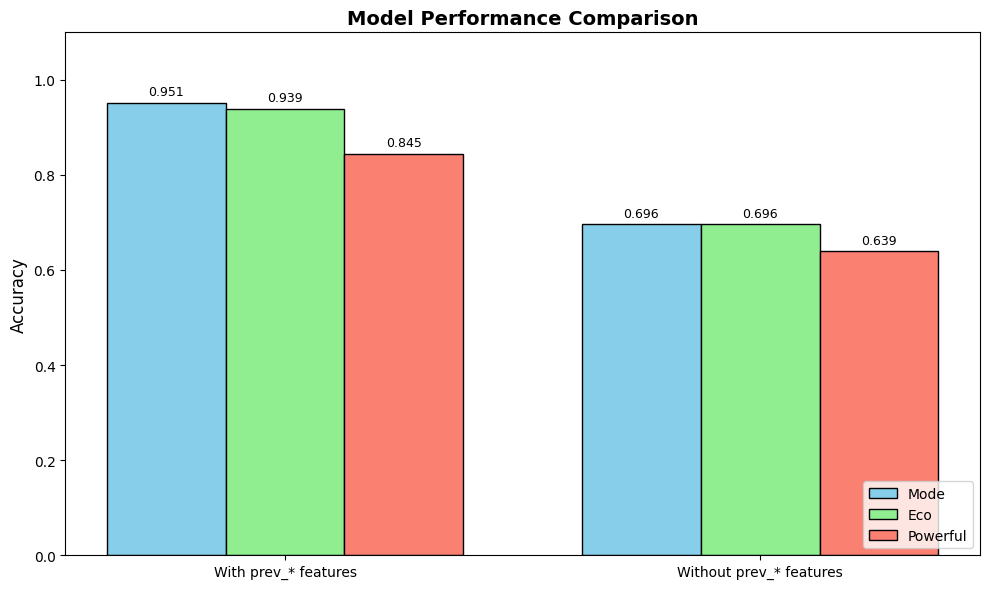

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Model performance data
models = ['With prev_* features', 'Without prev_* features']
mode_acc = [0.951, 0.696]
eco_acc = [0.939, 0.696]
powerful_acc = [0.845, 0.639]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, mode_acc, width, label='Mode', color='skyblue', edgecolor='black')
bars2 = ax.bar(x, eco_acc, width, label='Eco', color='lightgreen', edgecolor='black')
bars3 = ax.bar(x + width, powerful_acc, width, label='Powerful', color='salmon', edgecolor='black')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

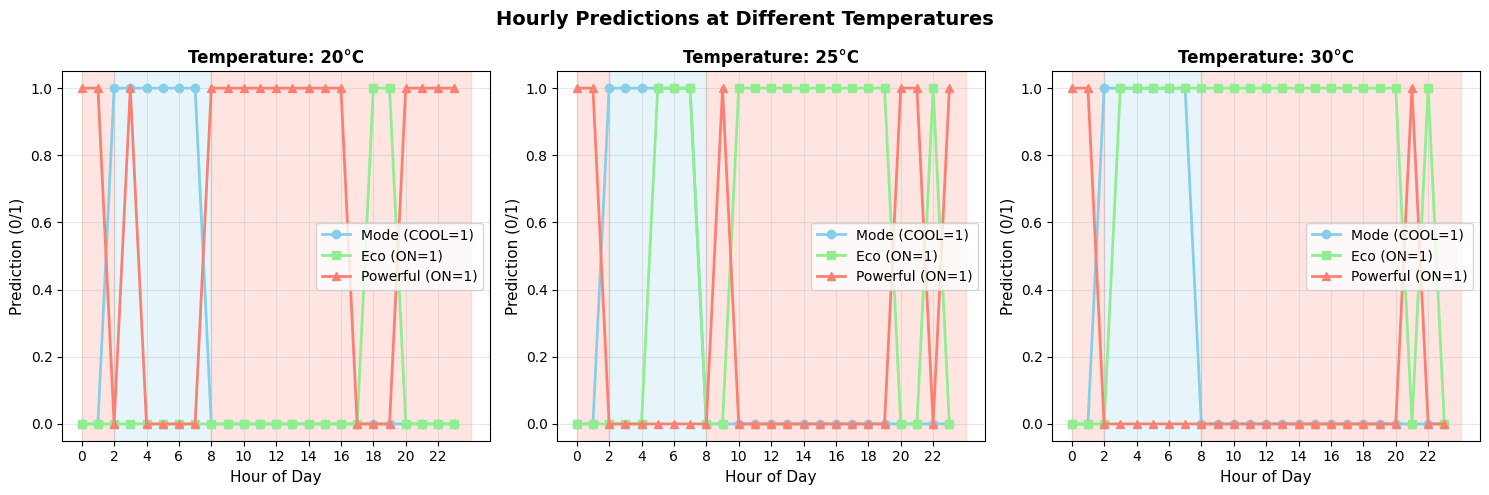

In [25]:
# Predict for a full day at different temperatures
hours = list(range(24))
temps = [20, 25, 30]  # Cool, moderate, hot
humidity = 50

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, temp in enumerate(temps):
    predictions = []
    for hour in hours:
        result = predict_ac(temp, humidity, hour)
        predictions.append({
            'mode': 1 if result['mode'] == 'COOL' else 0,
            'eco': 1 if result['eco'] == 'ON' else 0,
            'powerful': 1 if result['powerful'] == 'ON' else 0
        })
    
    ax = axes[idx]
    ax.plot(hours, [p['mode'] for p in predictions], 'o-', label='Mode (COOL=1)', 
            color='skyblue', linewidth=2, markersize=6)
    ax.plot(hours, [p['eco'] for p in predictions], 's-', label='Eco (ON=1)', 
            color='lightgreen', linewidth=2, markersize=6)
    ax.plot(hours, [p['powerful'] for p in predictions], '^-', label='Powerful (ON=1)', 
            color='salmon', linewidth=2, markersize=6)
    
    ax.set_xlabel('Hour of Day', fontsize=11)
    ax.set_ylabel('Prediction (0/1)', fontsize=11)
    ax.set_title(f'Temperature: {temp}°C', fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    
    # Highlight COOL period (2-8 AM)
    ax.axvspan(2, 8, alpha=0.2, color='skyblue', label='COOL Period')
    ax.axvspan(8, 24, alpha=0.2, color='salmon', label='HEAT Period')
    ax.axvspan(0, 2, alpha=0.2, color='salmon')

plt.suptitle('Hourly Predictions at Different Temperatures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

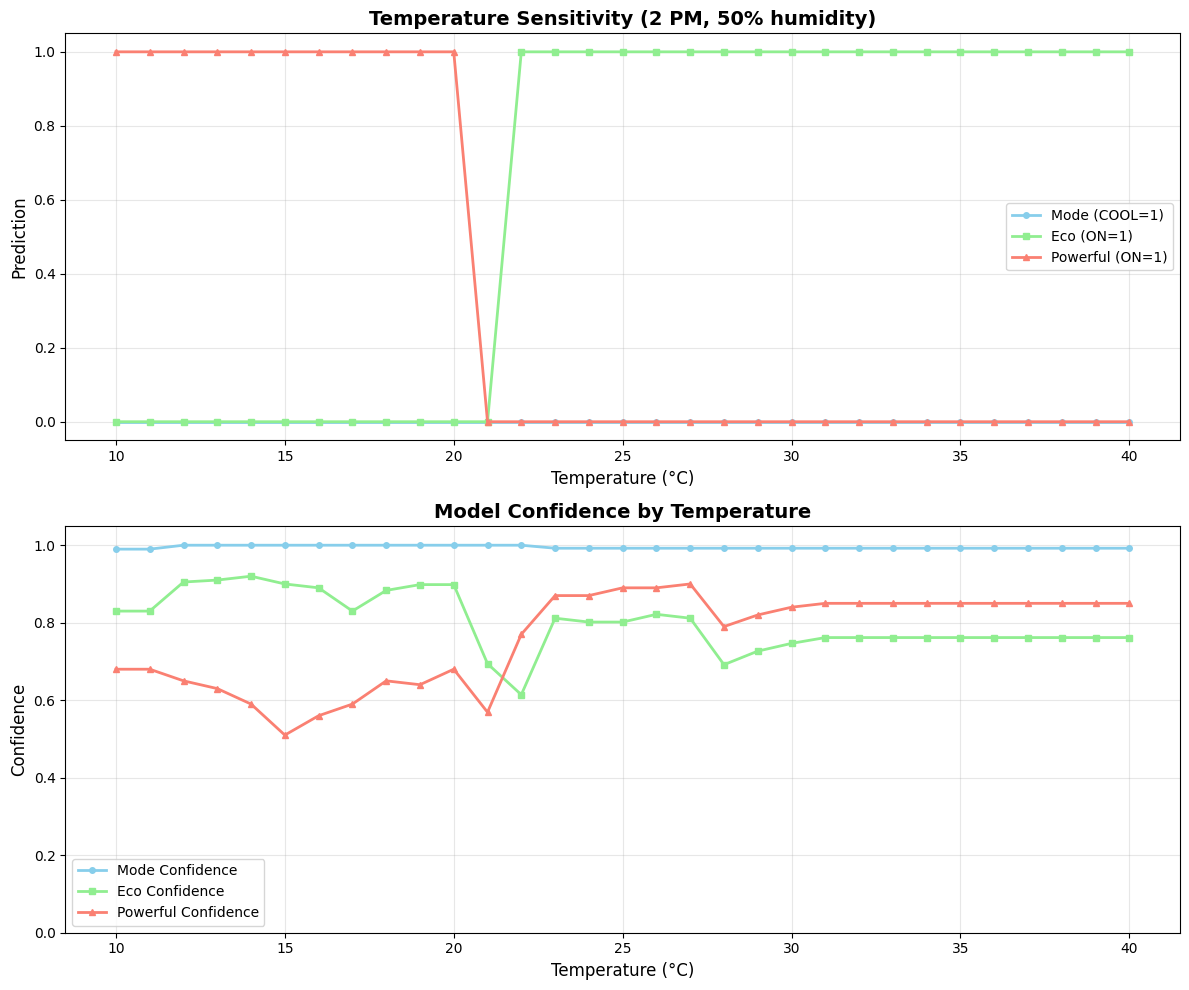

In [26]:
# Test temperature range
temps = list(range(10, 41))
humidity = 50
hour = 14  # 2 PM

predictions = []
for temp in temps:
    result = predict_ac(temp, humidity, hour)
    predictions.append({
        'temp': temp,
        'mode': result['mode'],
        'eco': result['eco'],
        'powerful': result['powerful'],
        'mode_conf': result['mode_confidence'],
        'eco_conf': result['eco_confidence'],
        'powerful_conf': result['powerful_confidence']
    })

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Predictions
ax1 = axes[0]
ax1.plot(temps, [1 if p['mode'] == 'COOL' else 0 for p in predictions], 
         'o-', label='Mode (COOL=1)', color='skyblue', linewidth=2, markersize=4)
ax1.plot(temps, [1 if p['eco'] == 'ON' else 0 for p in predictions], 
         's-', label='Eco (ON=1)', color='lightgreen', linewidth=2, markersize=4)
ax1.plot(temps, [1 if p['powerful'] == 'ON' else 0 for p in predictions], 
         '^-', label='Powerful (ON=1)', color='salmon', linewidth=2, markersize=4)

ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Prediction', fontsize=12)
ax1.set_title('Temperature Sensitivity (2 PM, 50% humidity)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(10, 41, 5))
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot 2: Confidence scores
ax2 = axes[1]
ax2.plot(temps, [p['mode_conf'] for p in predictions], 
         'o-', label='Mode Confidence', color='skyblue', linewidth=2, markersize=4)
ax2.plot(temps, [p['eco_conf'] for p in predictions], 
         's-', label='Eco Confidence', color='lightgreen', linewidth=2, markersize=4)
ax2.plot(temps, [p['powerful_conf'] for p in predictions], 
         '^-', label='Powerful Confidence', color='salmon', linewidth=2, markersize=4)

ax2.set_xlabel('Temperature (°C)', fontsize=12)
ax2.set_ylabel('Confidence', fontsize=12)
ax2.set_title('Model Confidence by Temperature', fontsize=14, fontweight='bold')
ax2.set_xticks(range(10, 41, 5))
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

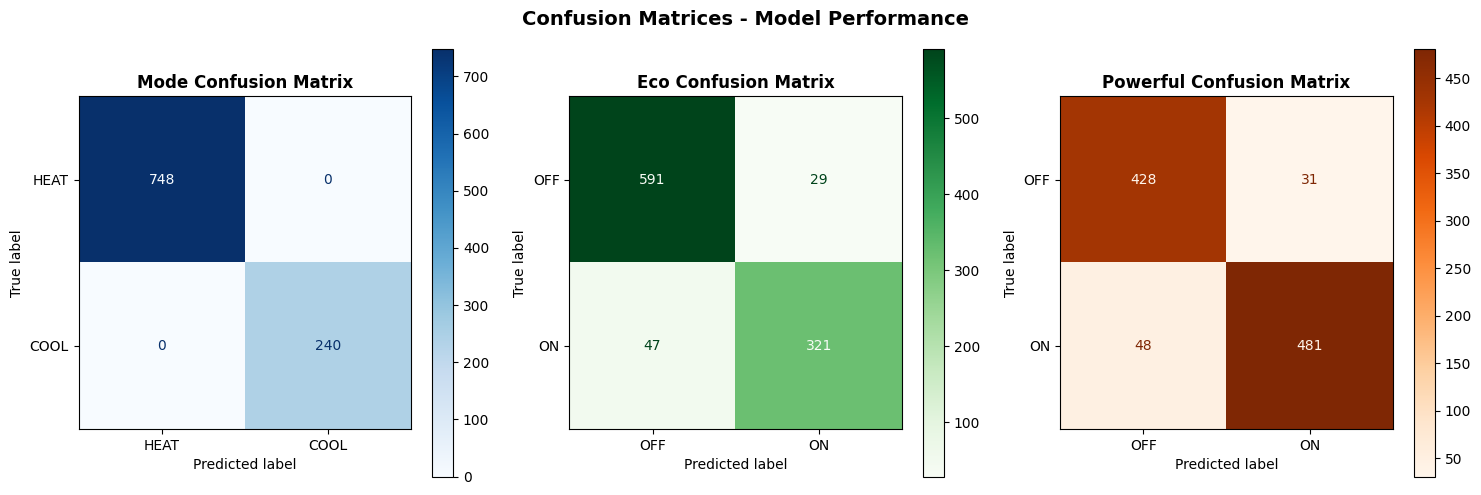


PERFORMANCE METRICS

Mode Classification Report:
              precision    recall  f1-score   support

        HEAT       1.00      1.00      1.00       748
        COOL       1.00      1.00      1.00       240

    accuracy                           1.00       988
   macro avg       1.00      1.00      1.00       988
weighted avg       1.00      1.00      1.00       988


Eco Classification Report:
              precision    recall  f1-score   support

         OFF       0.93      0.95      0.94       620
          ON       0.92      0.87      0.89       368

    accuracy                           0.92       988
   macro avg       0.92      0.91      0.92       988
weighted avg       0.92      0.92      0.92       988


Powerful Classification Report:
              precision    recall  f1-score   support

         OFF       0.90      0.93      0.92       459
          ON       0.94      0.91      0.92       529

    accuracy                           0.92       988
   macro avg     

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Get predictions on a test set
X_test = df_clean[feature_cols].values
y_mode_test = df_clean['mode'].values

# Predict
pred_mode_test = mode_model.predict(X_test)

# Create confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mode confusion matrix
cm_mode = confusion_matrix(y_mode_test, pred_mode_test)
disp_mode = ConfusionMatrixDisplay(confusion_matrix=cm_mode, display_labels=['HEAT', 'COOL'])
disp_mode.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Mode Confusion Matrix', fontsize=12, fontweight='bold')

# For Eco and Powerful, we need to use the appropriate models
# Let's create confusion matrices based on predictions
y_eco_test = df_clean['eco'].values
y_powerful_test = df_clean['powerful'].values

# Use mode-specific predictions (simplified - using all data with appropriate model)
pred_eco_test = []
pred_powerful_test = []
for i in range(len(X_test)):
    if y_mode_test[i] == 0:  # HEAT
        pred_eco_test.append(eco_model_heat.predict([X_test[i]])[0])
        pred_powerful_test.append(powerful_model_heat.predict([X_test[i]])[0])
    else:  # COOL
        pred_eco_test.append(eco_model_cool.predict([X_test[i]])[0])
        pred_powerful_test.append(powerful_model_cool.predict([X_test[i]])[0])

cm_eco = confusion_matrix(y_eco_test, pred_eco_test)
cm_powerful = confusion_matrix(y_powerful_test, pred_powerful_test)

disp_eco = ConfusionMatrixDisplay(confusion_matrix=cm_eco, display_labels=['OFF', 'ON'])
disp_eco.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Eco Confusion Matrix', fontsize=12, fontweight='bold')

disp_powerful = ConfusionMatrixDisplay(confusion_matrix=cm_powerful, display_labels=['OFF', 'ON'])
disp_powerful.plot(ax=axes[2], cmap='Oranges', values_format='d')
axes[2].set_title('Powerful Confusion Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print metrics
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)

from sklearn.metrics import classification_report

print("\nMode Classification Report:")
print(classification_report(y_mode_test, pred_mode_test, target_names=['HEAT', 'COOL']))

print("\nEco Classification Report:")
print(classification_report(y_eco_test, pred_eco_test, target_names=['OFF', 'ON']))

print("\nPowerful Classification Report:")
print(classification_report(y_powerful_test, pred_powerful_test, target_names=['OFF', 'ON']))

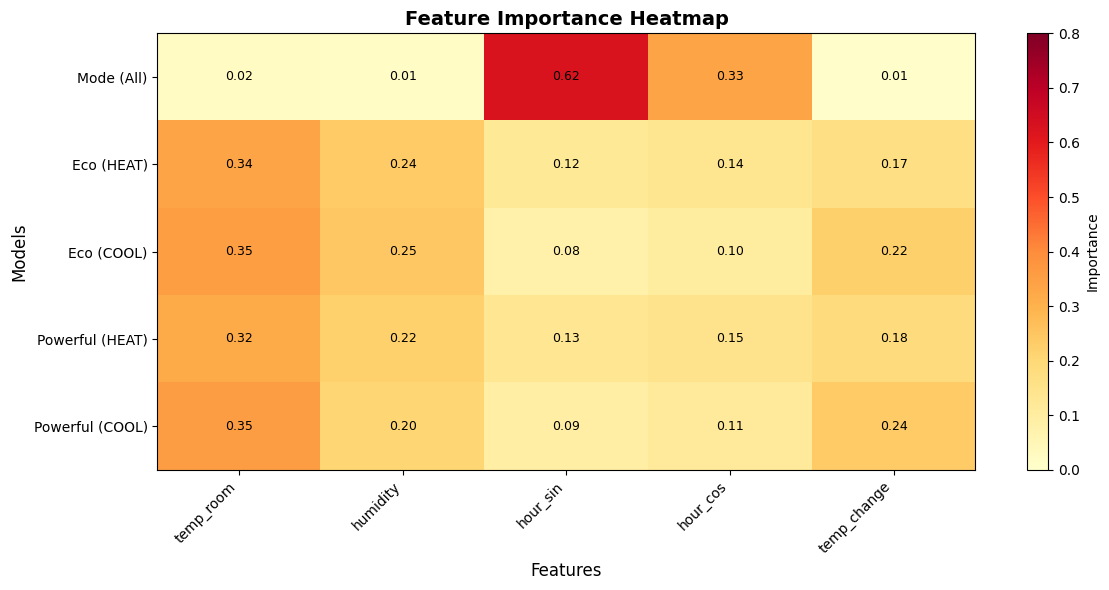

In [28]:
# Get feature importance for all models
feature_cols = metadata['feature_cols']

# Get importances
mode_importance = mode_model.feature_importances_
eco_heat_importance = eco_model_heat.feature_importances_
eco_cool_importance = eco_model_cool.feature_importances_
powerful_heat_importance = powerful_model_heat.feature_importances_
powerful_cool_importance = powerful_model_cool.feature_importances_

# Create DataFrame for heatmap
importance_data = pd.DataFrame({
    'Mode (All)': mode_importance,
    'Eco (HEAT)': eco_heat_importance,
    'Eco (COOL)': eco_cool_importance,
    'Powerful (HEAT)': powerful_heat_importance,
    'Powerful (COOL)': powerful_cool_importance
}, index=feature_cols)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(importance_data.values.T, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.8)

# Set labels
ax.set_xticks(np.arange(len(feature_cols)))
ax.set_yticks(np.arange(len(importance_data.columns)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_yticklabels(importance_data.columns)
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Models', fontsize=12)
ax.set_title('Feature Importance Heatmap', fontsize=14, fontweight='bold')

# Add colorbar
plt.colorbar(im, ax=ax, label='Importance')

# Add text annotations
for i in range(len(feature_cols)):
    for j in range(len(importance_data.columns)):
        text = ax.text(i, j, f'{importance_data.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

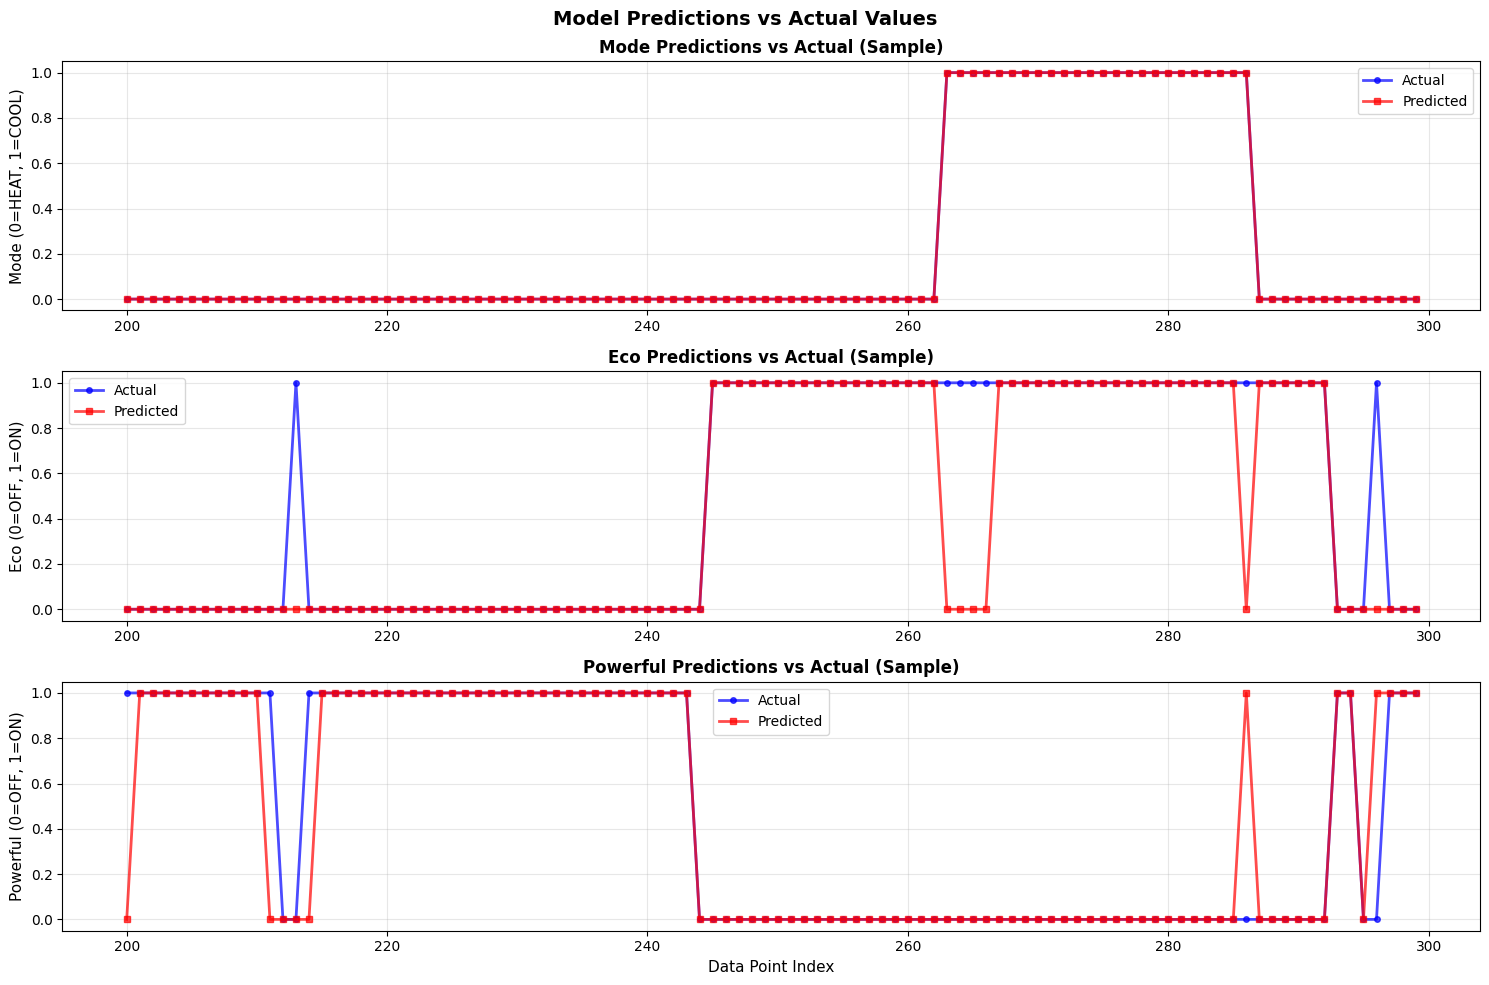


Sample Accuracy (last 100 samples):
  Mode: 100.0%
  Eco: 93.0%
  Powerful: 95.0%


In [29]:
# Take a sample of 100 consecutive predictions
sample_size = 100
sample_indices = range(200, 200 + sample_size)

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Get actual and predicted values for sample
actual_mode = df_clean.iloc[sample_indices]['mode'].values
pred_mode = mode_model.predict(df_clean.iloc[sample_indices][feature_cols].values)

# For eco and powerful, use mode-specific predictions
actual_eco = df_clean.iloc[sample_indices]['eco'].values
actual_powerful = df_clean.iloc[sample_indices]['powerful'].values

pred_eco = []
pred_powerful = []
for i in sample_indices:
    features = df_clean.iloc[[i]][feature_cols].values
    if mode_model.predict(features)[0] == 0:  # HEAT
        pred_eco.append(eco_model_heat.predict(features)[0])
        pred_powerful.append(powerful_model_heat.predict(features)[0])
    else:  # COOL
        pred_eco.append(eco_model_cool.predict(features)[0])
        pred_powerful.append(powerful_model_cool.predict(features)[0])

# Plot 1: Mode
axes[0].plot(sample_indices, actual_mode, 'o-', label='Actual', 
             color='blue', linewidth=2, markersize=4, alpha=0.7)
axes[0].plot(sample_indices, pred_mode, 's-', label='Predicted', 
             color='red', linewidth=2, markersize=4, alpha=0.7)
axes[0].set_ylabel('Mode (0=HEAT, 1=COOL)', fontsize=11)
axes[0].set_title('Mode Predictions vs Actual (Sample)', fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Eco
axes[1].plot(sample_indices, actual_eco, 'o-', label='Actual', 
             color='blue', linewidth=2, markersize=4, alpha=0.7)
axes[1].plot(sample_indices, pred_eco, 's-', label='Predicted', 
             color='red', linewidth=2, markersize=4, alpha=0.7)
axes[1].set_ylabel('Eco (0=OFF, 1=ON)', fontsize=11)
axes[1].set_title('Eco Predictions vs Actual (Sample)', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

# Plot 3: Powerful
axes[2].plot(sample_indices, actual_powerful, 'o-', label='Actual', 
             color='blue', linewidth=2, markersize=4, alpha=0.7)
axes[2].plot(sample_indices, pred_powerful, 's-', label='Predicted', 
             color='red', linewidth=2, markersize=4, alpha=0.7)
axes[2].set_ylabel('Powerful (0=OFF, 1=ON)', fontsize=11)
axes[2].set_xlabel('Data Point Index', fontsize=11)
axes[2].set_title('Powerful Predictions vs Actual (Sample)', fontsize=12, fontweight='bold')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Model Predictions vs Actual Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate accuracy on sample
mode_accuracy_sample = np.mean(actual_mode == pred_mode)
eco_accuracy_sample = np.mean(actual_eco == pred_eco)
powerful_accuracy_sample = np.mean(actual_powerful == pred_powerful)

print(f"\nSample Accuracy (last {sample_size} samples):")
print(f"  Mode: {mode_accuracy_sample:.1%}")
print(f"  Eco: {eco_accuracy_sample:.1%}")
print(f"  Powerful: {powerful_accuracy_sample:.1%}")